In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## Load Data / EDA

In [2]:
# Get directory of the current script
script_dir = Path.cwd()
csv_path = script_dir / "data" / "skater_data_2025-2025.csv"
data = pd.read_csv(csv_path)
print(data.head())
print(data.info())

   playerId  season             name team position situation  games_played  \
0   8478047    2024  Michael Bunting  NSH        L     other            76   
1   8478047    2024  Michael Bunting  NSH        L       all            76   
2   8478047    2024  Michael Bunting  NSH        L      5on5            76   
3   8478047    2024  Michael Bunting  NSH        L      4on5            76   
4   8478047    2024  Michael Bunting  NSH        L      5on4            76   

   icetime  shifts  gameScore  ...  OffIce_F_xGoals  OffIce_A_xGoals  \
0   2237.0    37.0      26.19  ...             7.28            10.09   
1  70819.0  1474.0      43.70  ...           161.54           187.75   
2  59813.0  1294.0      43.70  ...           112.73           122.08   
3      6.0     2.0       2.58  ...             0.20             0.17   
4   8763.0   141.0      36.88  ...            23.81             2.60   

   OffIce_F_shotAttempts  OffIce_A_shotAttempts  xGoalsForAfterShifts  \
0                   72.0 

There are 5 rows for each player and a ton of features that we likely don't care about.

Let's only consider 'all' situations of the game for each player. Otherwise there is duplicate data for other situations of the hockey game (5v4, 4v5, etc.)

In [3]:
df = data[data['situation'] == 'all']


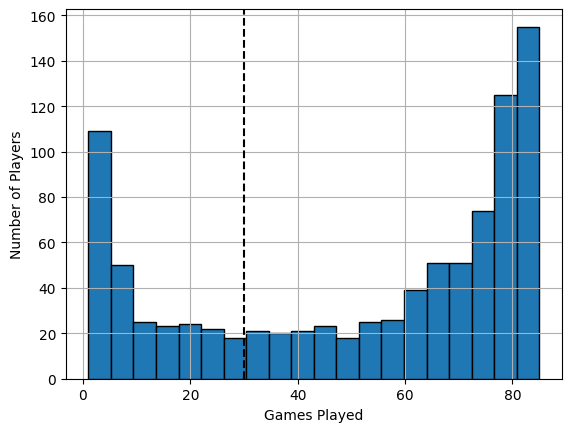

In [4]:
num_games_cutoff = 30
df['games_played'].hist(bins=20, edgecolor='black')
plt.xlabel('Games Played')
plt.ylabel('Number of Players')
plt.axvline(x=num_games_cutoff, color='black', linestyle='--')
plt.show()

Let's only consider players who played 30+ games over the course of the 82 game season. This eliminates some players who are only in the league for a short amount of time that may muddy up the clustering.

In [5]:
df = df[df['games_played'] >= num_games_cutoff]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 655 entries, 1 to 4596
Columns: 154 entries, playerId to fenwickAgainstAfterShifts
dtypes: float64(147), int64(3), object(4)
memory usage: 793.2+ KB


There are 154 features currently. I know that some of these won't be very useful in the clustering model just based on my background with ice hockey. I'll go ahead and manually do some feature selection. For many of these, I'll do some feature engineering and normalize them by the amount of time the player has been on the ice, so that it's not skewed toward players who get more ice time.

In [6]:
# Map player Id to name for easier lookup later
from sklearn.calibration import LabelEncoder


player_id_to_name = dict(zip(df['playerId'], df['name']))
columns_to_keep = [
    'playerId','position', 'icetime','gameScore','onIce_xGoalsPercentage',
    'onIce_corsiPercentage', 'onIce_fenwickPercentage', 'iceTimeRank', 'I_F_xOnGoal',
    'I_F_xGoals', 'I_F_xRebounds', 'I_F_flurryAdjustedxGoals', 'I_F_primaryAssists', 
    'I_F_secondaryAssists', 'I_F_shotsOnGoal', 'I_F_missedShots', 'I_F_blockedShotAttempts', 
    'I_F_shotAttempts', 'I_F_points', 'I_F_goals', 'I_F_rebounds', 'I_F_reboundGoals',
    'penalties', 'I_F_hits', 'I_F_takeaways', 'I_F_giveaways', 
    'I_F_lowDangerShots', 'I_F_mediumDangerShots', 'I_F_highDangerShots', 'I_F_lowDangerxGoals', 
    'I_F_mediumDangerxGoals', 'I_F_highDangerxGoals', 'I_F_lowDangerGoals', 'I_F_mediumDangerGoals', 
    'I_F_highDangerGoals', 'I_F_scoreAdjustedShotsAttempts', 'I_F_dZoneGiveaways',
    'I_F_reboundxGoals', 'I_F_oZoneShiftStarts', 'I_F_dZoneShiftStarts', 'I_F_neutralZoneShiftStarts', 
    'I_F_flyShiftStarts', 'faceoffsWon', 'faceoffsLost', 'penaltiesDrawn', 'shotsBlockedByPlayer',
    'OnIce_F_xGoals', 'OnIce_F_flurryAdjustedxGoals', 'OnIce_F_shotsOnGoal', 'OnIce_F_goals',
]
# Subset `df` to only the existing columns
df = df[columns_to_keep]

# Covert categorial data into numeric
s = (df.dtypes == 'object')
object_cols = list(s[s].index)
LE = LabelEncoder()
for i in object_cols:
    df[i]=df[[i]].apply(LE.fit_transform)

# Display cleaned df
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 655 entries, 1 to 4596
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   playerId                        655 non-null    int64  
 1   position                        655 non-null    int64  
 2   icetime                         655 non-null    float64
 3   gameScore                       655 non-null    float64
 4   onIce_xGoalsPercentage          655 non-null    float64
 5   onIce_corsiPercentage           655 non-null    float64
 6   onIce_fenwickPercentage         655 non-null    float64
 7   iceTimeRank                     655 non-null    float64
 8   I_F_xOnGoal                     655 non-null    float64
 9   I_F_xGoals                      655 non-null    float64
 10  I_F_xRebounds                   655 non-null    float64
 11  I_F_flurryAdjustedxGoals        655 non-null    float64
 12  I_F_primaryAssists              655 non-

## Use PCA to reduce dimensionality

In [ ]:
# Standardize the data
feature_names = df.columns.tolist()
X_scaled = StandardScaler().fit_transform(df)

# 2. PCA to keep components explaining 95% variance
pca = PCA(n_components=0.90, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

print("Original features:", df.shape[1])
print("Reduced features:", X_pca.shape[1])

# Global importance of features in explaining variance
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)
importance = (loadings.abs() * pca.explained_variance_ratio_).sum(axis=1)
print(importance.sort_values(ascending=False).head(10))


np.cumsum(pca.explained_variance_ratio_)


Original features: 50
Reduced features: 9
I_F_lowDangerShots                0.129359
I_F_highDangerShots               0.126385
I_F_highDangerxGoals              0.125402
I_F_flurryAdjustedxGoals          0.124765
I_F_xGoals                        0.124761
I_F_shotAttempts                  0.124716
I_F_scoreAdjustedShotsAttempts    0.124513
icetime                           0.124150
I_F_reboundxGoals                 0.124150
I_F_blockedShotAttempts           0.123164
dtype: float64


array([0.53401606, 0.69351547, 0.7592216 , 0.80411486, 0.82929464,
       0.85219305, 0.87062312, 0.88697815, 0.90069992])

Text(0, 0.5, 'Silhouette Score')

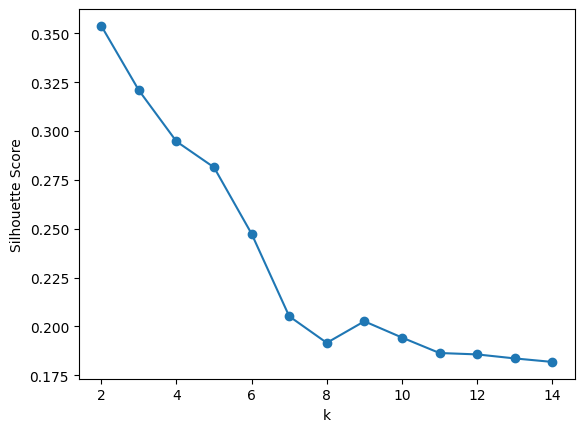

In [20]:
k_range = range(2, 15)
scores = []
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))
plt.plot(range(2, 15), scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")

# Clustering on PCA-reduced data
# kmeans = KMeans(n_clusters=5, random_state=0)
# labels = kmeans.fit_predict(X_pca)

to do:
- convert numeric values to be usable in algo
- feature engineer some stuff -- normalze by time on ice, turn into percentage (faceoffs0)

Models to look into:
- pca
- k means
- soft clustering? / gaussian mixture model?